Name: Gaurav Santosh Mane RollNo: 13253

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
df.shape

(768, 9)

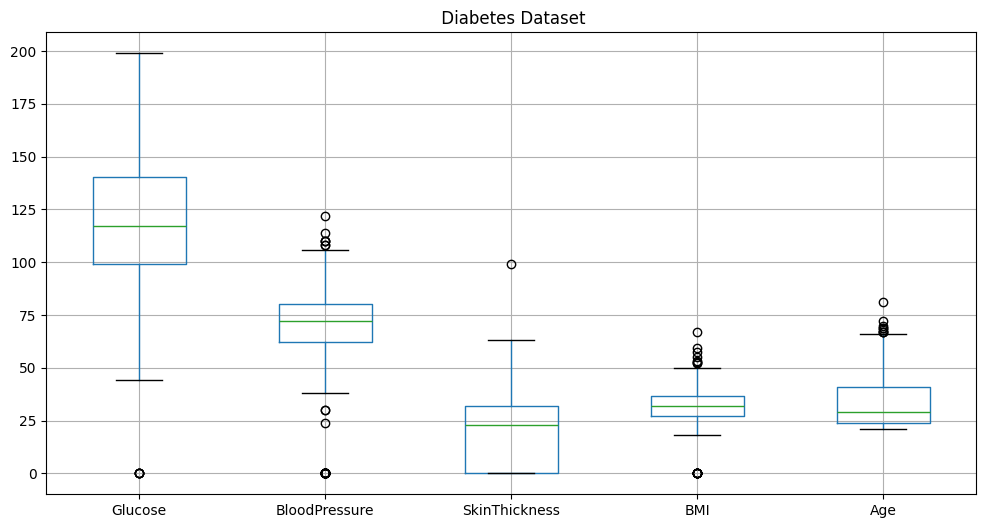

In [6]:
cols = ['Glucose','BloodPressure','SkinThickness','BMI','Age']
df[cols].boxplot(figsize=(12,6))
plt.title(" Diabetes Dataset")
plt.show()


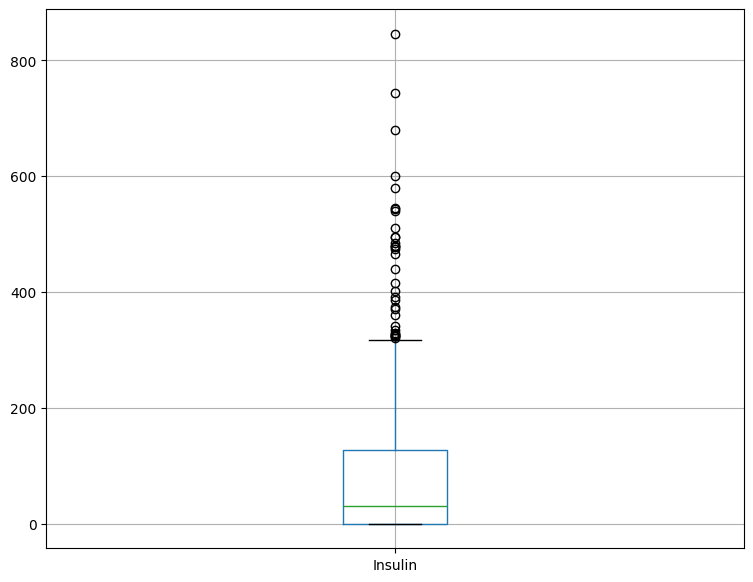

In [7]:
col=['Insulin']
df[col].boxplot(figsize=(9,7))
plt.show()


In [8]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in cols:df[col] = df[col].replace(0, np.nan)
df


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [10]:
for col in cols: df[col] = df[col].fillna(df[col].median())


In [12]:
for col in df.columns[:-1]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower}")
    print(f"Upper Bound: {upper}")
    df[col] = df[col].clip(lower, upper)


IQR: 5.0
Lower Bound: -6.5
Upper Bound: 13.5
IQR: 40.5
Lower Bound: 39.0
Upper Bound: 201.0
IQR: 16.0
Lower Bound: 40.0
Upper Bound: 104.0
IQR: 7.0
Lower Bound: 14.5
Upper Bound: 42.5
IQR: 5.75
Lower Bound: 112.875
Upper Bound: 135.875
IQR: 9.100000000000001
Lower Bound: 13.849999999999998
Upper Bound: 50.25
IQR: 0.38249999999999995
Lower Bound: -0.32999999999999996
Upper Bound: 1.2
IQR: 17.0
Lower Bound: -1.5
Upper Bound: 66.5


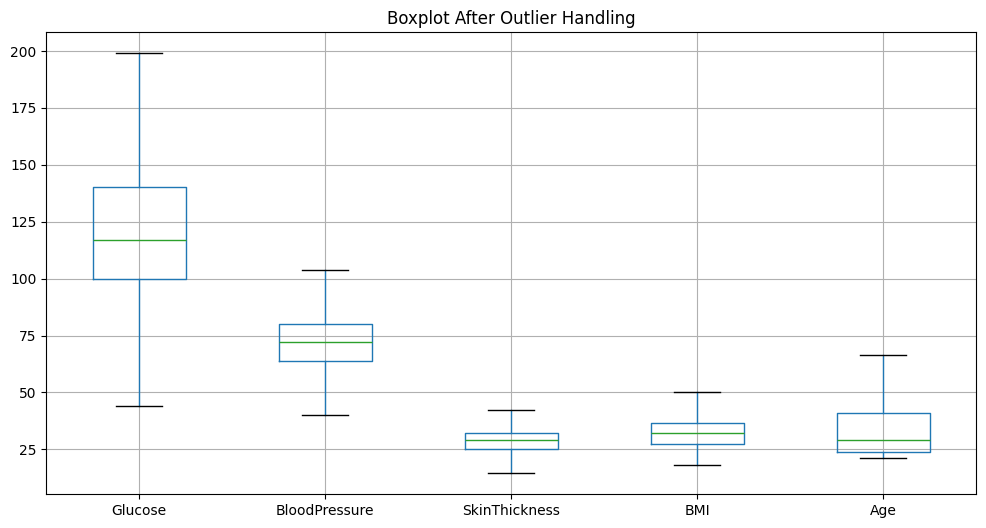

In [13]:
col= ['Glucose','BloodPressure','SkinThickness','BMI','Age']
df[col].boxplot(figsize=(12,6))
plt.title("Boxplot After Outlier Handling")
plt.show()


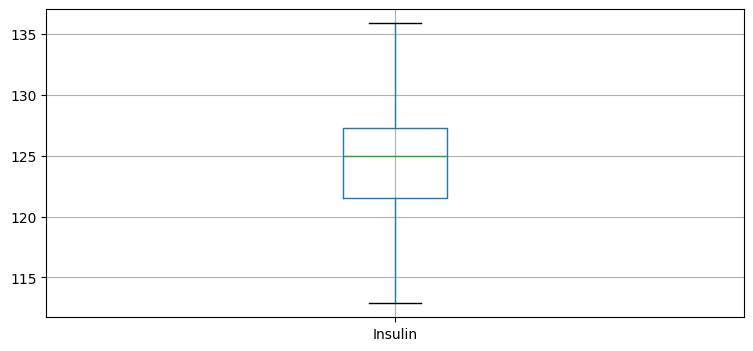

In [14]:
col=['Insulin']
df[col].boxplot(figsize=(9,4))
plt.show()


In [15]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']


In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [18]:
from sklearn.naive_bayes import GaussianNB
gaussian = GaussianNB()
gaussian.fit(X_train, y_train)


GaussianNB()

In [19]:
Y_pred = gaussian.predict(X_test)


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
accuracy = accuracy_score(y_test, Y_pred)
precision = precision_score(y_test, Y_pred)
recall = recall_score(y_test, Y_pred)
cm = confusion_matrix(y_test, Y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.7012987012987013
Precision: 0.5714285714285714
Recall: 0.6545454545454545


In [22]:
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[72 27]
 [19 36]]


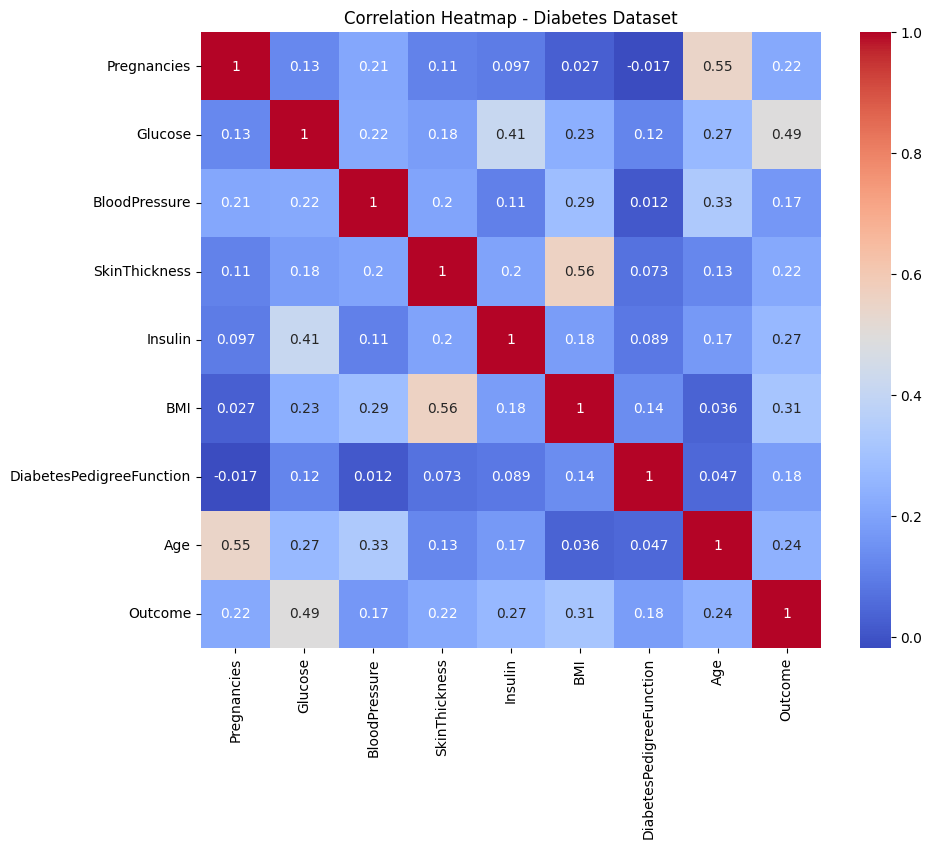

In [23]:
import seaborn as sns
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap - Diabetes Dataset")
plt.show()



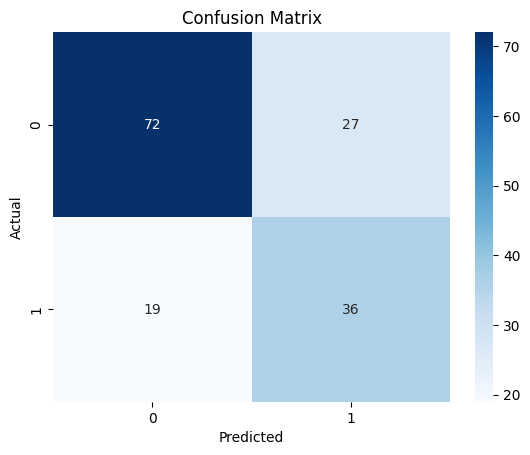

In [24]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")
plt.show()
